### 오늘의 목표
 - 순환신경망을 이용하여 로이터 뉴스를 카테고리별로 분류해보자.
 - 다야한 순환신경망에 대해 알아보자.

In [ ]:
# 데이터 다루기 위한 라이브러리 가져오기

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 데이터 가져오기 (도구 불러오기)

from tensorflow.keras.datasets import reuters

In [ ]:
# 데이터 가져오기 (분할을 하면서 데이터 가져오기)

(X_train, y_train), (X_test, y_test) = reuters.load_data()

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(8982,)
(8982,)
(2246,)
(2246,)


In [ ]:
X_train

array([list([1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]),
       list([1, 3267, 699, 3434, 2295, 56, 16784, 7511, 9, 56, 3906, 1073, 81, 5, 1198, 57, 366, 737, 132, 20, 4093, 7, 19261, 49, 2295, 13415, 1037, 3267, 699, 3434, 8, 7, 10, 241, 16, 855, 129, 231, 783, 5, 4, 587, 2295, 13415, 30625, 775, 7, 48, 34, 191, 44, 35, 1795, 505, 17, 12]),
       list([1, 53, 12, 284, 15, 14, 272, 26, 53, 959, 32, 818, 15, 14, 272, 26, 39, 684, 70, 11, 14, 12, 3886, 18, 180, 183, 187, 70, 11, 14, 102, 32, 11, 29, 53, 44, 704, 15, 14, 19, 758, 15, 53, 959, 47, 1013, 15, 14, 19, 132, 15, 39, 965, 32, 11, 14, 147, 72, 11, 180, 183, 187, 44, 11, 14, 102, 19, 11, 123, 186, 90, 67, 960, 4

### 데이터 확인
 - 기존의 뉴스기사 데이터와 다른 형태의 데이터
 - 이 데이터는 수치 변환 및 토큰화가 이미 진행되어 있는 데이터 셋
 - 사전에 전처리를 이미 완료된 데이터다.
 - 우리가 전처리를 처음부터 하는 것이 아닌 우리가 사용할 형태에 맞춰서 진행만 해주면 된다.
 - 빈도수를 기반으로 수치화를 진행한 데이터 => 숫자가 작을수록 많이 등장한 데이터

In [ ]:
# 단어사전 확인

pd.Series(reuters.get_word_index()).sort_values()

,0
the,1
of,2
to,3
in,4
said,5
...,...
recirculation,30975
capco,30976
figueras,30977
jung,30978


In [ ]:
np.unique(y_train)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

### 정답 데이터 확인 결과
 - 정답의 종류는 46종류 => 다중분류
 - 정답을 위한 원-핫-인코딩 진행을 해야한다.
 - 출력층 : units : 46 / acti : softmax
 - loss함수 : categorica_crossentropy

In [ ]:
# 정답데이터 원-핫-인코딩 진행

y_train_oh = pd.get_dummies(y_train)
y_test_oh = pd.get_dummies(y_test)

In [ ]:
# 문제데이터 전처리 작업 진행
# 학습 데이터를 확인하여 길이를 맞춰주기 -> timesteps를 맞춰야 하기 때문
# 길이가 짧을 경우 0으로 채워서 확장하는 Padding기법을 사용
# 길이가 너무 길 경우에는 단어를 잘라서 축소 시키기

In [ ]:
# 데이터 확인
# 뉴스 문장에 적절한 길이를 찾기 위해 train 전체의 문장의 길이를 확인해보기

train_len = []   # 각 길이를 담을 리스트
for doc in X_train:
    train_len.append(len(doc))

In [ ]:
# 기술 통계량 확인

pd.Series(train_len).describe()

,0
count,8982.000000
mean,145.539857
std,145.822248
min,13.000000
25%,60.000000
50%,95.000000
75%,179.000000
max,2376.000000


### 데이터의 길이 확인 결과
 - 최소값은 : 13
 - 최댓값 : 2376
 - 평균값 : 145
 - 중앙값 : 95
 - 75% : 179
 - 무조건 최댓값에 맞춰서 데이터를 변형시킬 경우에는 순환횟수가 너무 많아져서 학습속도가 느려지고 기억손실이 일어나 제대로된 학습이 불가능하다.
 - 따라서 데이터 별로 길이를 확인하여 적절한 값으로 맞춰서 데이터를 사용해야 한다.
 - 적절한 데이터의 길이는 150 ~ 200으로 추정
 - 우리는 학습을 하는데 의의를 두기 위해 120정도로 설정

In [ ]:
# timestep을 120으로 설정하기

from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# 문장의 최대 길이를 120으로 설정하여 짧은 문장의 경우에는 padding을 사용항 0으로 채우고
# 긴 문장에 대해서는 120에 맞춰서 자르기

X_train_seq = pad_sequences(X_train, maxlen = 120)
X_test_seq = pad_sequences(X_test, maxlen = 120)

In [ ]:
print(X_train_seq[0])

[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     1 27595 28842
     8    43    10   447     5    25   207   270     5  3095   111    16
   369   186    90    67     7    89     5    19   102     6    19   124
    15    90    67    84    22   482    26     7    48     4    49     8
   864    39   209   154     6   151     6    83    11    15    22   155
    11    15     7    48     9  4579  1005   504     6   258     6   272
    11    15    22   134    44    11    15    16     8   197  1245    90
    67    52    29   209    30    32   132     6   109    15    17    12]


In [ ]:
print(X_train_seq.shape)
print(X_test_seq.shape)

(8982, 120)
(2246, 120)


In [ ]:
# 순환신경망을 사용하기 위해 특성 차원을 추가하기 (차원을 늘리기)

X_train_rs = X_train_seq.reshape(8982, 120, 1)   # reshape(X_train_seq.shape[0], X_train_seq.shape[1],1)  <= 괄호내용 대체가능
X_test_rs = X_test_seq.reshape(2246, 120, 1)

In [ ]:
# 순환신경망을 사용하기 위한 데이터 전처리 완료

print(X_train_rs.shape)
print(X_test_rs.shape)
print(y_train_oh.shape)
print(y_test_oh.shape)

(8982, 120, 1)
(2246, 120, 1)
(8982, 46)
(2246, 46)


### 신경망 설계
 - 순환신경망을 사용하기 위해 데이터셋 준비 완료
 - 순환신경망을 사용해보기

In [ ]:
# 도구 불러오기

from tensorflow.keras import Sequential   # 뼈대 도구
from tensorflow.keras.layers import Dense, SimpleRNN, InputLayer   # 신경망 층 도구

### 순환신경망
 - 일반적으로 순환신경망은 다층 입력 단층 출력의 구조를 가지고 있다.
 - 여러개의 순환신경망을 쌓을 때는 다층 입력 다층 출력 구조로 변경을 해줘야한다.
 - return_sequences = True => 해줘야만 다층 출력으로 구조를 변경할 수 있다.

In [ ]:
# 신경망 구축
# 뼈대 생성

model1 = Sequential()


# 입력층 쌓기

model1.add(InputLayer(shape = (120, 1)))   # 입력 데이터 특성에 맞춰서 설정


# RNN 층

model1.add(SimpleRNN(units = 128, activation = 'tanh', return_sequences = True))
model1.add(SimpleRNN(units = 64, activation = 'tanh', return_sequences = True))
model1.add(SimpleRNN(units = 32, activation = 'tanh'))

# ============================ RNN 층 ==============================

# MLP 층 쌓기

model1.add(Dense(units = 64, activation = 'relu'))


# 출력층

model1.add(Dense(units = 46, activation = 'softmax'))

In [ ]:
# 모델 학습방법 및 평가방법 설정

model1.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [ ]:
# 학습진행

model1.fit(
    X_train_rs, y_train_oh,
    epochs = 50,
    validation_split = 0.2
)

Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.3539 - loss: 2.4412 - val_accuracy: 0.3528 - val_loss: 2.3672
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.3698 - loss: 2.3434 - val_accuracy: 0.3600 - val_loss: 2.3077
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.3869 - loss: 2.2848 - val_accuracy: 0.3801 - val_loss: 2.3353
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.3865 - loss: 2.2582 - val_accuracy: 0.3823 - val_loss: 2.2551
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.3928 - loss: 2.2308 - val_accuracy: 0.3990 - val_loss: 2.2321
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.4045 - loss: 2.2064 - val_accuracy: 0.3923 - val_loss: 2.2502
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4102 - loss: 2.1991 - val_accuracy: 0.4046 - val_loss: 2.2086
Epoch 8/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.4199 - loss: 2.1828 - val_acc

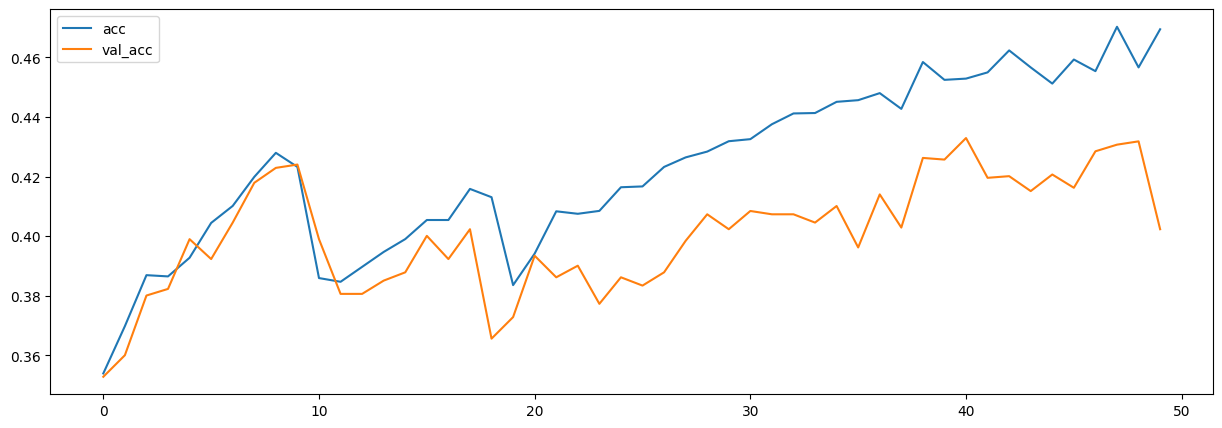

In [ ]:
# 시각화 진행

plt.figure(figsize = (15, 5))
plt.plot(model1.history.history['accuracy'], label = 'acc')
plt.plot(model1.history.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()

### 결과확인
 - 정확도가 향상이 되면서 진행되고 있지만 높은편은 아니다.

### 성능을 높이는 방법
 - 더 좋은 성능의 모델 사용
 - 데이터 전처리 진행 (빈도기반이 아닌 의미 분석을 위한 고차원의 벡터화 방법을 사용 (임베딩))
 - 많은 데이터 확보
 - 파라미터 값 조정 등

### RNN 모델 특징
 - 기본적인 RNN 구조는 긴 시퀀스를 가지는 데이터를 효과적으로 학습하기는 어렵다.
 - 문장의 길이가 엄청 길지는 않더라도, RNN성능은 조금만 길이가 길어지면 기억손실이 일어나 성능이 떨어질 가능성이 매우 높다.
 - 순환횟수가 길어 질 수록 초반 입력된 단어의 기억 데이터가 손실되는 현상이 발생
 - 문장 구성시 초반 단어가 후반 단어에 영향을 많이 끼치는 데이터일수록 SimpleRNN의 성능은 좋지 않을 가능성이 높다.

### 단점을 보안한 모델
#### LSTM(Long Short Term Memory)
 - 장기기억, 단기기억에 대해 관리계산이 추가된 모델
 - 연산이 복잡해져 학습이 오래걸리고 모델이 무겁지만 기억손실이 줄어들어 성능면에서는 좋을 가능성이 높다.

In [ ]:
# LSTM 불러오기

from tensorflow.keras.layers import LSTM

In [ ]:
# 신경망 구현

model2 = Sequential()


# 입력층

model2.add(InputLayer(shape = (120, 1)))


# LSTM 층 쌓기

model2.add(LSTM(units = 128, activation = 'tanh', return_sequences = True))
model2.add(LSTM(units = 64, activation = 'tanh', return_sequences = True))
model2.add(LSTM(units = 32, activation = 'tanh'))

# ========================== LSTM 층 ==========================

# MLP층 쌓기

model2.add(Dense(units = 64, activation = 'relu'))


# 출력층 쌓기

model2.add(Dense(units = 46, activation = 'softmax'))

In [ ]:
#  학습방법 및 평가방법 설정

model2.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [ ]:
# 학습

model2.fit(
    X_train_rs, y_train_oh,
    epochs = 20
)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.4302 - loss: 2.3159 - val_accuracy: 0.4591 - val_loss: 2.1241
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4630 - loss: 2.1276 - val_accuracy: 0.4636 - val_loss: 2.0942
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.4676 - loss: 2.1038 - val_accuracy: 0.4697 - val_loss: 2.1076
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4674 - loss: 2.0768 - val_accuracy: 0.4674 - val_loss: 2.0983
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4718 - loss: 2.0547 - val_accuracy: 0.4741 - val_loss: 2.0135
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.4688 - loss: 2.0352 - val_accuracy: 0.4869 - val_loss: 2.0205
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4764 - loss: 2.0150 - val_accuracy: 0.4747 - val_loss: 1.9833
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4816 - loss: 1.9885 - val_acc

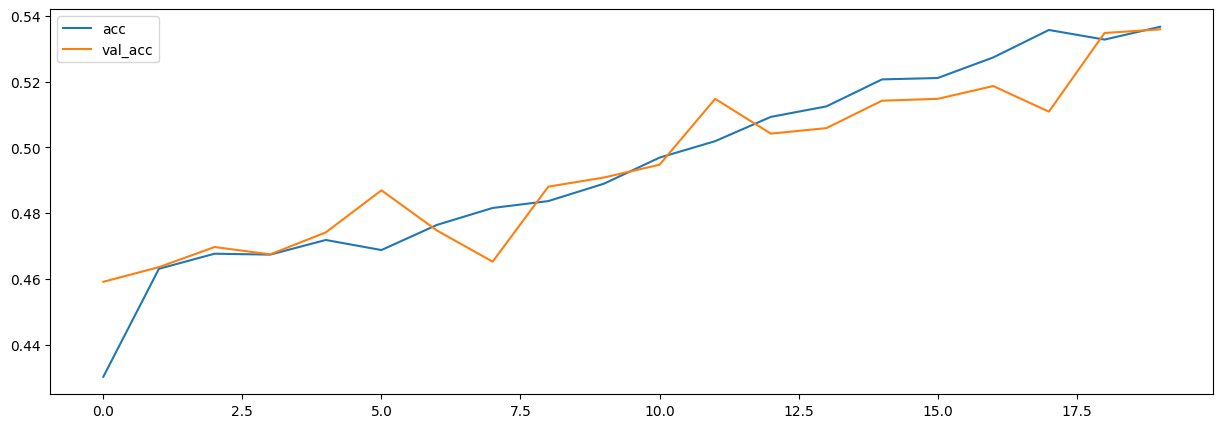

In [ ]:
# 시각화 진행

plt.figure(figsize = (15, 5))
plt.plot(model2.history.history['accuracy'], label = 'acc')
plt.plot(model2.history.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()

### 임베딩 레이어 추가하기
 - 현재 로이터 뉴스는 단어사전에 부여된 번호 패턴을 보고 학습하는 구조
 - 각 단어의 의미를 학습시키려면 임베딩레이어를 추가

In [ ]:
from tensorflow.keras.layers import Embedding   # 임베딩레이어

In [ ]:
# 뼈대 구성

model = Sequential()


# 입력층

model.add(InputLayer(shape = (120, )))
# 임베딩레이어 : 학습을 통해서 입력된 데이터(단어)의 정보를 정교한 실수형태로 학습하거나 변환하는 레이어
# input_dim = 단어사전에 등록된 단어 수 => 임베딩벡터의 갯수를 의미
# output_dim = 한 단어를 표현하는 숫자의 갯수
model.add(Embedding(input_dim = 30979, output_dim = 128))


# 중간층

model.add(LSTM(units = 128, activation = 'tanh', return_sequences = True))
model.add(LSTM(units = 64, activation = 'tanh', return_sequences = True))
model.add(LSTM(units = 32, activation = 'tanh'))
model.add(Dense(units = 64, activation = 'relu'))

# 출력층

model.add(Dense(units = 46, activation = 'softmax'))

In [ ]:
model.compile(
    loss = "categorical_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

In [ ]:
# 학습

model.fit(
    X_train_rs, y_train_oh,
    epochs = 40,
    validation_split = 0.2
)

Epoch 1/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9285 - loss: 0.2672 - val_accuracy: 0.7652 - val_loss: 1.2352
Epoch 2/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9328 - loss: 0.2521 - val_accuracy: 0.7668 - val_loss: 1.2523
Epoch 3/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9385 - loss: 0.2339 - val_accuracy: 0.7679 - val_loss: 1.3193
Epoch 4/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9415 - loss: 0.2204 - val_accuracy: 0.7629 - val_loss: 1.3474
Epoch 5/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9427 - loss: 0.2118 - val_accuracy: 0.7629 - val_loss: 1.3998
Epoch 6/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9410 - loss: 0.2158 - val_accuracy: 0.7624 - val_loss: 1.3849
Epoch 7/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9379 - loss: 0.2238 - val_accuracy: 0.7468 - val_loss: 1.4538
Epoch 8/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9381 - loss: 0.2254 - val_accu

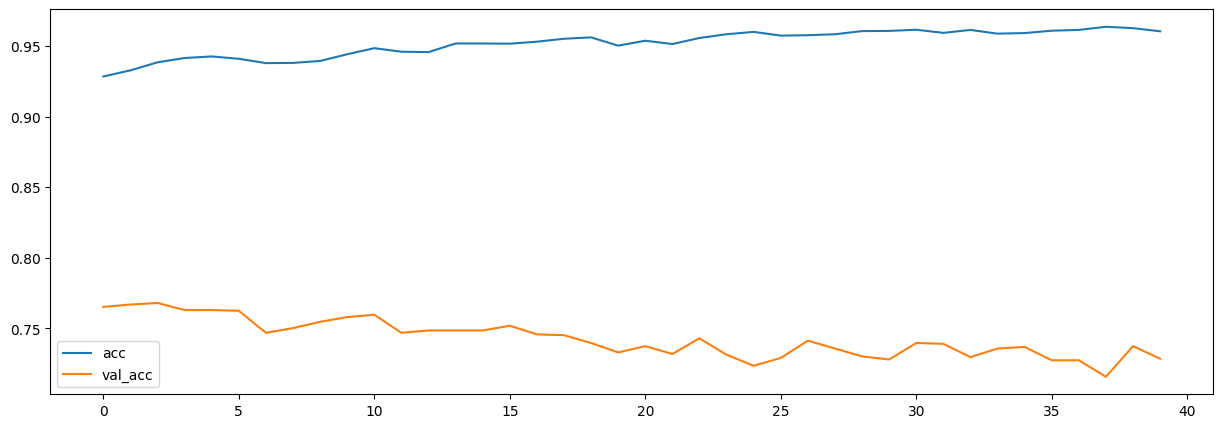

In [ ]:
# 시각화 진행

plt.figure(figsize = (15, 5))
plt.plot(model.history.history['accuracy'], label = 'acc')
plt.plot(model.history.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()

### 모델 수정해보기
 - 현재 모델은 훈련데이터에 대한 이해도가 빠르게 올라갔지만 검증데이터에 대한 이해도는 일정수준에 그친다.
 - 모델구조, 단어사전의 수, 임베딩 벡터의 길이 등을 변경해서 개선이 가능한지 실습해보자.

In [ ]:
# 뼈대 구성

model = Sequential()


# 입력층

model.add(InputLayer(shape = (120, )))
# 임베딩레이어 : 학습을 통해서 입력된 데이터(단어)의 정보를 정교한 실수형태로 학습하거나 변환하는 레이어
# input_dim = 단어사전에 등록된 단어 수 => 임베딩벡터의 갯수를 의미
# output_dim = 한 단어를 표현하는 숫자의 갯수
model.add(Embedding(input_dim = 30979, output_dim = 128))


# 중간층

model.add(LSTM(units = 128, activation = 'tanh'))


# 출력층

model.add(Dense(units = 46, activation = 'softmax'))

In [ ]:
model.compile(
    loss = "categorical_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

In [ ]:
# 학습

model.fit(
    X_train_rs, y_train_oh,
    epochs = 40,
    validation_split = 0.2
)

Epoch 1/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4412 - loss: 2.1985 - val_accuracy: 0.4491 - val_loss: 1.9754
Epoch 2/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5113 - loss: 1.8482 - val_accuracy: 0.5008 - val_loss: 1.9012
Epoch 3/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5763 - loss: 1.6065 - val_accuracy: 0.5949 - val_loss: 1.5900
Epoch 4/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6455 - loss: 1.3489 - val_accuracy: 0.5938 - val_loss: 1.5570
Epoch 5/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7151 - loss: 1.0870 - val_accuracy: 0.6433 - val_loss: 1.4589
Epoch 6/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7791 - loss: 0.8463 - val_accuracy: 0.6594 - val_loss: 1.5039
Epoch 7/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8338 - loss: 0.6574 - val_accuracy: 0.6650 - val_loss: 1.4561
Epoch 8/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8683 - loss: 0.5163 - val_accu

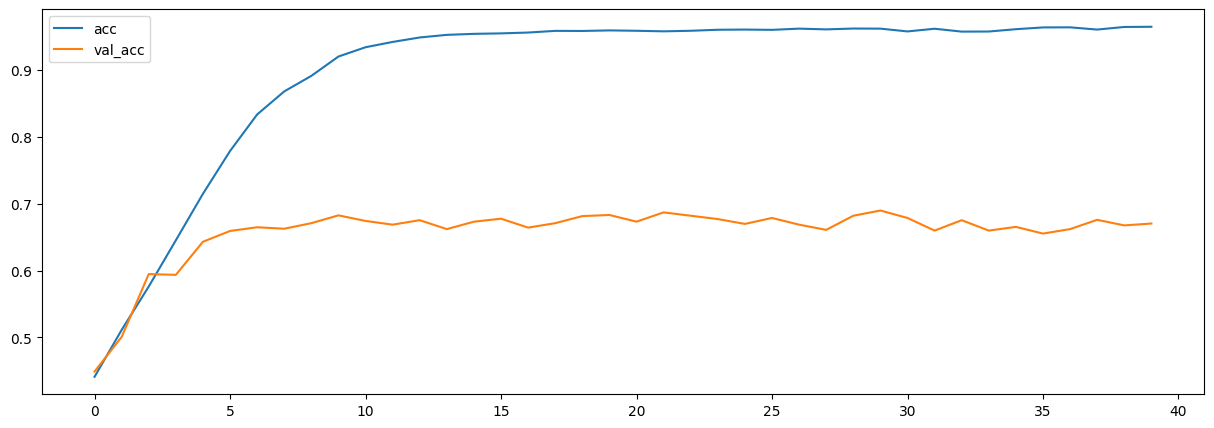

In [ ]:
# 시각화 진행

plt.figure(figsize = (15, 5))
plt.plot(model.history.history['accuracy'], label = 'acc')
plt.plot(model.history.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()

In [ ]:
# 단어사전 수, 임베딩벡터 길이 조절해보기
# 데이터 가져오기 (분할을 하면서 데이터 가져오기)
# num_words => 빈도가 높은 상위 8000개 단어만 단어사전에 등록해서 활용하기

(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words = 8000)

In [ ]:
X_train[0]

[1,
 2,
 2,
 8,
 43,
 10,
 447,
 5,
 25,
 207,
 270,
 5,
 3095,
 111,
 16,
 369,
 186,
 90,
 67,
 7,
 89,
 5,
 19,
 102,
 6,
 19,
 124,
 15,
 90,
 67,
 84,
 22,
 482,
 26,
 7,
 48,
 4,
 49,
 8,
 864,
 39,
 209,
 154,
 6,
 151,
 6,
 83,
 11,
 15,
 22,
 155,
 11,
 15,
 7,
 48,
 9,
 4579,
 1005,
 504,
 6,
 258,
 6,
 272,
 11,
 15,
 22,
 134,
 44,
 11,
 15,
 16,
 8,
 197,
 1245,
 90,
 67,
 52,
 29,
 209,
 30,
 32,
 132,
 6,
 109,
 15,
 17,
 12]

In [ ]:
X_train_seq = pad_sequences(X_train, maxlen = 120)
X_test_seq = pad_sequences(X_test, maxlen = 120)
X_train_rs = X_train_seq.reshape(8982, 120, 1)
X_test_rs = X_test_seq.reshape(2246, 120, 1)

In [ ]:
# 모델구조 변경

# 뼈대 구성

model = Sequential()


# 입력층

model.add(InputLayer(shape = (120, )))
# 임베딩레이어 : 학습을 통해서 입력된 데이터(단어)의 정보를 정교한 실수형태로 학습하거나 변환하는 레이어
# input_dim = 단어사전에 등록된 단어 수 => 임베딩벡터의 갯수를 의미
# output_dim = 한 단어를 표현하는 숫자의 갯수
model.add(Embedding(input_dim = 8000, output_dim = 128))


# 중간층

model.add(LSTM(units = 128, activation = 'tanh'))


# 출력층

model.add(Dense(units = 46, activation = 'softmax'))

In [ ]:
model.compile(
    loss = "categorical_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

In [ ]:
# 학습

model.fit(
    X_train_rs, y_train_oh,
    epochs = 40,
    validation_split = 0.2
)

Epoch 1/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4231 - loss: 2.2747 - val_accuracy: 0.5298 - val_loss: 1.9322
Epoch 2/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5321 - loss: 1.7881 - val_accuracy: 0.5531 - val_loss: 1.7347
Epoch 3/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5804 - loss: 1.6323 - val_accuracy: 0.5721 - val_loss: 1.6912
Epoch 4/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6277 - loss: 1.5019 - val_accuracy: 0.6455 - val_loss: 1.4561
Epoch 5/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6813 - loss: 1.2886 - val_accuracy: 0.6439 - val_loss: 1.4517
Epoch 6/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7262 - loss: 1.0916 - val_accuracy: 0.6639 - val_loss: 1.3430
Epoch 7/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7685 - loss: 0.9166 - val_accuracy: 0.6789 - val_loss: 1.3318
Epoch 8/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8097 - loss: 0.7484 - val_accurac

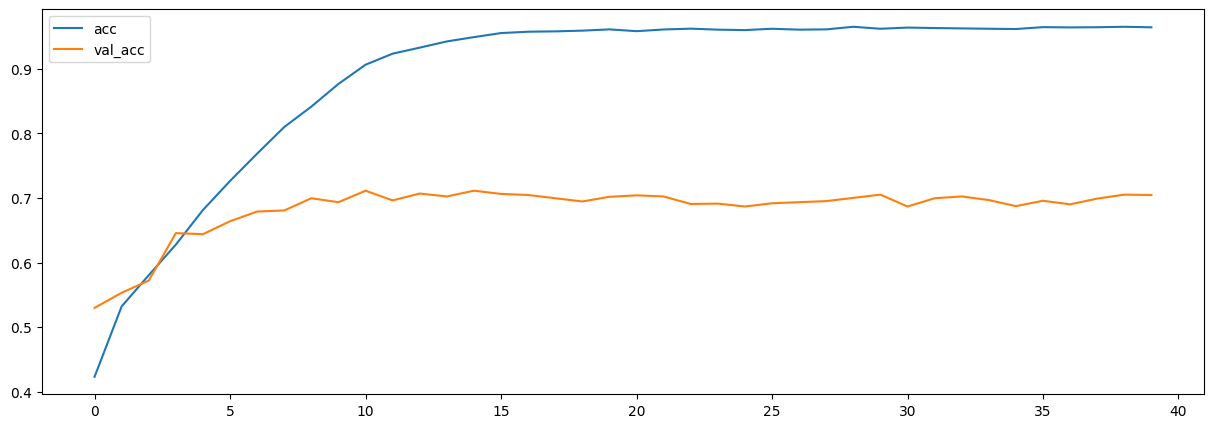

In [ ]:
# 시각화 진행

plt.figure(figsize = (15, 5))
plt.plot(model.history.history['accuracy'], label = 'acc')
plt.plot(model.history.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()

### 임베딩 벡터 만들기 실습
 - 구글에서 발표한 Word2Vec 모델을 사용.
 - Word2Vec 단어끼리의 관계성을 통해 단어의 의미를 정교한 실수로 만들어내는 것을 최종 목적으로 둔 모델.
 - 이후에 Glove, FastText 등이 등장했고, 현대 LLM은 임베딩을 기본적으로 탑재해서 활용하고 있다.

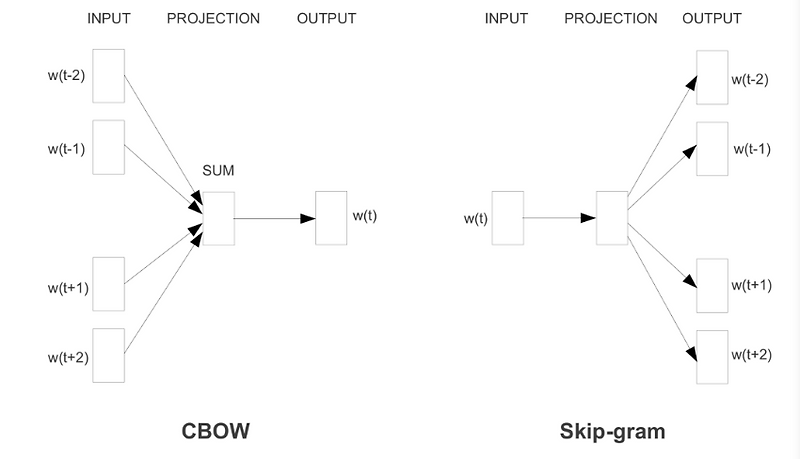

In [ ]:
# 필요한 패키지 설치

!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [71]:
naver_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/딥러닝/data/naver_shopping.txt",
                       delimiter = "\t", header = None)

In [72]:
naver_df.columns = ['평점', '리뷰']
naver_df.head()

,평점,리뷰
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ


In [73]:
!pip install kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 12.8 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.23.0-py3-none-any.whl size=88067826 sha256=def9a5b0360651c5d3808c1c2c830b8f70f7251a1e60dd25138fb0d64ec8ae79
  Stored in directory: /root/.cache/pip/wheels/f2/94/da/ff88b4c2305cd1f3effc8001b5f42f16dc9931bcd84d1e77c3
Successfully built kiwipiepy_model


In [74]:
from kiwipiepy import Kiwi
kiwi = Kiwi()

In [75]:
naver_df['형태소'] = naver_df['리뷰'].apply(lambda x : kiwi.tokenize(x))

In [76]:
naver_df.head()

,평점,리뷰,형태소
0,5,배공빠르고 굿,"[(배, NNG, 0, 1), (공, NNG, 1, 1), (빠르, VA, 2, 2..."
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"[(택배, NNG, 0, 2), (가, JKS, 2, 1), (엉망, NNG, 4,..."
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"[(아주, MAG, 0, 2), (좋, VA, 2, 1), (어요, EF, 3, 2..."
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"[(선물, NNG, 0, 2), (용, XSN, 2, 1), (으로, JKB, 3,..."
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,"[(민트, NNG, 0, 2), (색상, NNG, 2, 2), (예쁘, VA, 5,..."


In [77]:
naver_df['형태소'].iloc[0]

[Token(form='배', tag='NNG', start=0, len=1),
 Token(form='공', tag='NNG', start=1, len=1),
 Token(form='빠르', tag='VA', start=2, len=2),
 Token(form='고', tag='EC', start=4, len=1),
 Token(form='굿', tag='NNG', start=6, len=1)]

In [78]:
# 품사가 명사, 형용사, 동사인 단어 필터링

naver_df['형태소_필터링'] = naver_df['형태소'].apply(lambda x : [token.form for token in x if token.tag in ['VV', 'VA', 'NNG']])

In [79]:
naver_df.head()

,평점,리뷰,형태소,형태소_필터링
0,5,배공빠르고 굿,"[(배, NNG, 0, 1), (공, NNG, 1, 1), (빠르, VA, 2, 2...","[배, 공, 빠르, 굿]"
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"[(택배, NNG, 0, 2), (가, JKS, 2, 1), (엉망, NNG, 4,...","[택배, 엉망, 집, 밑, 층, 말, 놔두, 가]"
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"[(아주, MAG, 0, 2), (좋, VA, 2, 1), (어요, EF, 3, 2...","[좋, 바지, 좋, 구매, 가격, 대박, 바느질, 편하, 가성비, 최고]"
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"[(선물, NNG, 0, 2), (용, XSN, 2, 1), (으로, JKB, 3,...","[선물, 전달, 상품, 머그, 컵, 오, 당황, 전화, 주, 하, 배송, 누락, 확..."
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,"[(민트, NNG, 0, 2), (색상, NNG, 2, 2), (예쁘, VA, 5,...","[민트, 색상, 예쁘, 옆, 손잡이, 용도, 사용]"


In [81]:
# 학습

import gensim.models

model = gensim.models.Word2Vec(
    sentences = naver_df['형태소_필터링'],   # 학습시킬 데이터셋
    sg = 1,   # 1은 skip-gram방식 / 0은 CBOW 방식
    window = 3,   # 중심단어와 주변단어의 관계를 어느 거리까지 볼껀지 설정
    min_count = 5,   # 최소 등장하는 단어 횟수
    vector_size = 50   # 단어를 임베딩할 벡터 크기
)

In [93]:
# 임베딩 벡터 확인

keyword = '민트'
keyword_vector = model.wv[keyword]

In [94]:
keyword_vector

array([-0.0324339 , -0.5528504 ,  0.05443978, -0.16786861, -0.13474108,
        0.35489175,  0.13363184,  0.2903368 , -0.15654427, -0.09267052,
       -0.01953247, -0.5890372 ,  0.41241667,  0.17030251, -0.4703368 ,
        0.54825175,  0.1760597 ,  0.35459962,  0.31859887, -0.6534934 ,
        0.5674152 ,  0.2206537 ,  1.0106149 , -0.32301098,  0.18931356,
        0.05691641, -0.8233468 ,  0.54316324, -0.44849297,  1.0710584 ,
       -0.31046548,  0.19778696,  0.13181859, -0.70531565, -0.35231313,
        0.14791016,  0.0714585 , -0.32925555, -0.01987147,  0.07954434,
        0.5891029 , -0.02660024, -0.5585136 , -0.07983976,  0.13929285,
       -0.15554945, -0.35137737, -0.51475185,  0.35511717,  0.03399254],
      dtype=float32)

In [102]:
# 연관단어 확인하기

keyword = '택배'
rs = model.wv.most_similar(keyword, topn = 20)

In [103]:
rs

[('화물', 0.8099693059921265),
 ('우체국', 0.8097519278526306),
 ('배달', 0.788727879524231),
 ('파업', 0.7847610712051392),
 ('업체', 0.775338888168335),
 ('물류', 0.7743039727210999),
 ('무인', 0.7650150060653687),
 ('죄송하', 0.7635778188705444),
 ('거래', 0.7571933269500732),
 ('조회', 0.7530366778373718),
 ('물건', 0.7529443502426147),
 ('찾아가', 0.7517213821411133),
 ('비우', 0.7511206269264221),
 ('신선식품', 0.7506893277168274),
 ('분실', 0.7471920251846313),
 ('황당하', 0.7460440993309021),
 ('우편', 0.7437546253204346),
 ('로젠택배', 0.7411839365959167),
 ('지역', 0.7410389184951782),
 ('회사', 0.7406827211380005)]